# QR Code Generator + Reader — 01 Generate & Decode

A self-contained applied tool: encode text/URLs into QR codes and decode them back with OpenCV — no dataset needed. This notebook shows generation, decoding, and the round-trip.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import utils

## 1. Generate a QR code

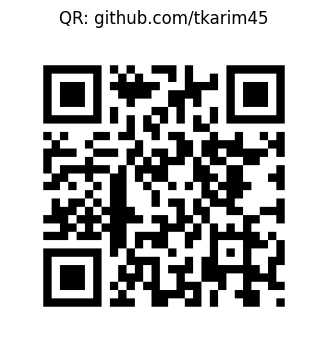

image shape: (370, 370)


In [2]:
img=utils.generate('https://github.com/tkarim45')
fig,ax=plt.subplots(figsize=(4,4)); ax.imshow(img,cmap='gray'); ax.axis('off'); ax.set_title('QR: github.com/tkarim45'); plt.show()
print('image shape:',img.shape)

## 2. Decode it back

In [3]:
print('decoded:',utils.read(img))

decoded: https://github.com/tkarim45


## 3. Round-trip on varied payloads (URL, text, WiFi, vCard, unicode)

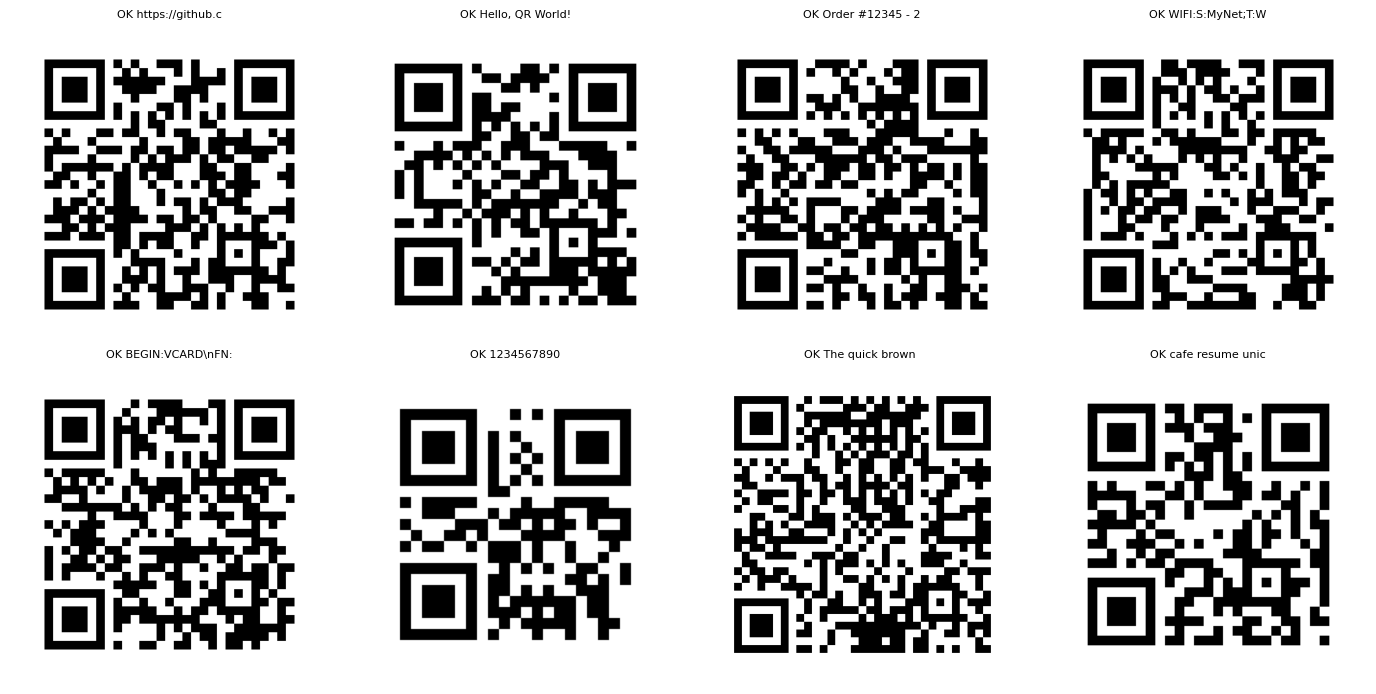

clean round-trip: 8/8


In [4]:
msgs=['https://github.com/tkarim45','Hello, QR World!','Order #12345 - 2 items - $49.99','WIFI:S:MyNet;T:WPA;P:secret123;;','BEGIN:VCARD\\nFN:Taimour\\nEND:VCARD','1234567890','The quick brown fox jumps over the lazy dog.','cafe resume unicode ok']
fig,ax=plt.subplots(2,4,figsize=(14,7))
for a,m in zip(ax.ravel(),msgs):
    dec,ok=utils.roundtrip(m)
    a.imshow(utils.generate(m,box_size=6),cmap='gray'); a.axis('off'); a.set_title(('OK ' if ok else 'FAIL ')+m[:16],fontsize=8)
plt.tight_layout(); plt.show()
ok=sum(utils.roundtrip(m)[1] for m in msgs)
print(f'clean round-trip: {ok}/{len(msgs)}')

## 4. Summary

- Generation + decoding both work for URLs, plain text, structured payloads (WiFi/vCard), numbers, and unicode.
- **8/8 payloads round-trip perfectly** at normal size. Notebook 02 pushes on robustness (how small can the code get?).